In [66]:
import sys
print(sys.executable)

c:\Users\ycode\Desktop\2nd_YouCode\briefs\Prediction_Prix_Immobilier\venv\Scripts\python.exe


In [67]:
# ===== Imports =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ===== Configuration =====
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# ===== Chemins =====
DATA_PATH = '../data/raw/House_Prices_original.csv'

# ===== Versions =====
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"seaborn : {sns.__version__}")

pandas  : 3.0.6
numpy   : 2.5.3
seaborn : 0.13.2


In [68]:
# ===== Chargement =====
df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset chargé")
print(f"Shape : {df.shape}")
print(f"Lignes : {df.shape[0]:,}")
print(f"Colonnes : {df.shape[1]}")

✅ Dataset chargé
Shape : (2919, 81)
Lignes : 2,919
Colonnes : 81


In [69]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706.00,Unf,0.00,150.00,856.00,GasA,Ex,Y,SBrkr,856,854,0,1710,1.00,0.00,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.00",RFn,2.00,548.00,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,"208,500.00"
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.00,Unf,0.00,284.00,"1,262.00",GasA,Ex,Y,SBrkr,1262,0,0,1262,0.00,1.00,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.00",RFn,2.00,460.00,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,"181,500.00"
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.00,Unf,0.00,434.00,920.00,GasA,Ex,Y,SBrkr,920,866,0,1786,1.00,0.00,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.00",RFn,2.00,608.00,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,"223,500.00"
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216.00,Unf,0.00,540.00,756.00,GasA,Gd,Y,SBrkr,961,756,0,1717,1.00,0.00,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.00",Unf,3.00,642.00,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,"140,000.00"
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655.00,Unf,0.00,490.00,"1,145.00",GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.00,0.00,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.00",RFn,3.00,836.00,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,"250,000.00"


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   str    
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   str    
 6   Alley          198 non-null    str    
 7   LotShape       2919 non-null   str    
 8   LandContour    2919 non-null   str    
 9   Utilities      2917 non-null   str    
 10  LotConfig      2919 non-null   str    
 11  LandSlope      2919 non-null   str    
 12  Neighborhood   2919 non-null   str    
 13  Condition1     2919 non-null   str    
 14  Condition2     2919 non-null   str    
 15  BldgType       2919 non-null   str    
 16  HouseStyle     2919 non-null   str    
 17  OverallQual    2919 non-null   int64  
 18  OverallCond    2919

In [71]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,"2,919.00","1,460.00",842.79,1.00,730.50,"1,460.00","2,189.50","2,919.00"
MSSubClass,"2,919.00",57.14,42.52,20.00,20.00,50.00,70.00,190.00
LotFrontage,"2,433.00",69.31,23.34,21.00,59.00,68.00,80.00,313.00
LotArea,"2,919.00","10,168.11","7,887.00","1,300.00","7,478.00","9,453.00","11,570.00","215,245.00"
OverallQual,"2,919.00",6.09,1.41,1.00,5.00,6.00,7.00,10.00
OverallCond,"2,919.00",5.56,1.11,1.00,5.00,5.00,6.00,9.00
YearBuilt,"2,919.00","1,971.31",30.29,"1,872.00","1,953.50","1,973.00","2,001.00","2,010.00"
YearRemodAdd,"2,919.00","1,984.26",20.89,"1,950.00","1,965.00","1,993.00","2,004.00","2,010.00"
MasVnrArea,"2,896.00",102.20,179.33,0.00,0.00,0.00,164.00,"1,600.00"
BsmtFinSF1,"2,918.00",441.42,455.61,0.00,0.00,368.50,733.00,"5,644.00"


In [72]:
# ===== Valeurs manquantes =====
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Nb manquants': missing,
    'Pourcentage': missing_pct
}).sort_values('Nb manquants', ascending=False)

# Uniquement les colonnes avec au moins 1 manquant
missing_df[missing_df['Nb manquants'] > 0]

,Nb manquants,Pourcentage
PoolQC,2909,99.66
MiscFeature,2814,96.40
Alley,2721,93.22
Fence,2348,80.44
MasVnrType,1766,60.50
FireplaceQu,1420,48.65
LotFrontage,486,16.65
GarageYrBlt,159,5.45
GarageCond,159,5.45
GarageQual,159,5.45


In [73]:
print("Répartition des types de colonnes :")
print(df.dtypes.value_counts())
print()
print(f"Colonnes numériques    : {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Colonnes catégorielles : {df.select_dtypes(include=['object']).shape[1]}")

Répartition des types de colonnes :
str        43
int64      26
float64    12
Name: count, dtype: int64

Colonnes numériques    : 38
Colonnes catégorielles : 43


In [74]:
print("Variable cible : SalePrice")
print(f"Type            : {df['SalePrice'].dtype}")
print(f"Min             : {df['SalePrice'].min():,.0f}")
print(f"Max             : {df['SalePrice'].max():,.0f}")
print(f"Moyenne         : {df['SalePrice'].mean():,.0f}")
print(f"Médiane         : {df['SalePrice'].median():,.0f}")
print(f"Écart-type      : {df['SalePrice'].std():,.0f}")
print(f"Valeurs manquantes : {df['SalePrice'].isnull().sum()}")

Variable cible : SalePrice
Type            : float64
Min             : 34,900
Max             : 755,000
Moyenne         : 180,053
Médiane         : 176,735
Écart-type      : 57,382
Valeurs manquantes : 0


In [75]:
# ===== Vérification de l'origine du fichier =====
print("Id min :", df['Id'].min())
print("Id max :", df['Id'].max())
print("Nb lignes :", len(df))
print()

# Compter les lignes avec Id <= 1460 (train Kaggle)
train_part = df[df['Id'] <= 1460]
test_part  = df[df['Id'] > 1460]

print(f"Lignes Id <= 1460 : {len(train_part)}")
print(f"Lignes Id >  1460 : {len(test_part)}")
print()

# Vérifier si SalePrice est rempli sur les 2 parties
print("SalePrice manquants (Id<=1460) :", train_part['SalePrice'].isnull().sum())
print("SalePrice manquants (Id>1460)  :", test_part['SalePrice'].isnull().sum())

Id min : 1
Id max : 2919
Nb lignes : 2919

Lignes Id <= 1460 : 1460
Lignes Id >  1460 : 1459

SalePrice manquants (Id<=1460) : 0
SalePrice manquants (Id>1460)  : 0


In [76]:
# ===== Extraction du vrai train (Id 1 -> 1460) =====
df_full = pd.read_csv('../data/raw/House_Prices_original.csv')
df_train = df_full[df_full['Id'] <= 1460].copy().reset_index(drop=True)

print(f"Shape : {df_train.shape}")
print(f"Id    : {df_train['Id'].min()} → {df_train['Id'].max()}")
print(f"SalePrice moyenne : {df_train['SalePrice'].mean():,.0f}")
print(f"SalePrice médiane : {df_train['SalePrice'].median():,.0f}")
print(f"SalePrice min/max : {df_train['SalePrice'].min():,.0f} / {df_train['SalePrice'].max():,.0f}")

# Écrase train.csv avec la version propre
df_train.to_csv('../data/raw/train.csv', index=False)
print("\n✅ data/raw/train.csv remplacé (1460 lignes)")

Shape : (1460, 81)
Id    : 1 → 1460
SalePrice moyenne : 180,921
SalePrice médiane : 163,000
SalePrice min/max : 34,900 / 755,000

✅ data/raw/train.csv remplacé (1460 lignes)


In [77]:
# ===== Doublons stricts (hors Id) =====
cols_sans_id = [c for c in df.columns if c != 'Id']
nb_dups = df.duplicated(subset=cols_sans_id).sum()
print(f"Doublons stricts (hors Id) : {nb_dups}")

if nb_dups > 0:
    dups = df[df.duplicated(subset=cols_sans_id, keep=False)].sort_values('Id')
    print(f"\nLignes concernées : {len(dups)}")
    print(dups[['Id', 'GrLivArea', 'OverallQual', 'YearBuilt', 'SalePrice']])

Doublons stricts (hors Id) : 0


In [78]:
print(f"Id dupliqués : {df['Id'].duplicated().sum()}")
print(f"Id uniques   : {df['Id'].nunique()}")

Id dupliqués : 0
Id uniques   : 2919


In [79]:
print("Surface habitable (GrLivArea) :")
print(f"  Min : {df['GrLivArea'].min()} (attendu : 334)")
print(f"  Max : {df['GrLivArea'].max()} (attendu : 5642)")
print(f"  Valeurs <= 0 : {(df['GrLivArea'] <= 0).sum()}")

print("\nSous-sol (TotalBsmtSF) :")
print(f"  Min : {df['TotalBsmtSF'].min()}")
print(f"  Valeurs < 0 : {(df['TotalBsmtSF'] < 0).sum()}")

print("\nSurface 1er étage (1stFlrSF) :")
print(f"  Min : {df['1stFlrSF'].min()}")
print(f"  Valeurs <= 0 : {(df['1stFlrSF'] <= 0).sum()}")

Surface habitable (GrLivArea) :
  Min : 334 (attendu : 334)
  Max : 5642 (attendu : 5642)
  Valeurs <= 0 : 0

Sous-sol (TotalBsmtSF) :
  Min : 0.0
  Valeurs < 0 : 0

Surface 1er étage (1stFlrSF) :
  Min : 334
  Valeurs <= 0 : 0


In [80]:
print("Année de construction :")
print(f"  Min : {df['YearBuilt'].min()} (attendu : 1872)")
print(f"  Max : {df['YearBuilt'].max()} (attendu : 2010)")
print(f"  YearBuilt > YrSold : {(df['YearBuilt'] > df['YrSold']).sum()}")

print("\nAnnée de rénovation :")
print(f"  Min : {df['YearRemodAdd'].min()}")
print(f"  YearRemodAdd < YearBuilt : {(df['YearRemodAdd'] < df['YearBuilt']).sum()}")

print("\nAnnée de garage :")
print(f"  Min : {df['GarageYrBlt'].min()}")
print(f"  Max : {df['GarageYrBlt'].max()} (attendu : 2010)")
print(f"  GarageYrBlt > YrSold : {(df['GarageYrBlt'] > df['YrSold']).sum()}")

Année de construction :
  Min : 1872 (attendu : 1872)
  Max : 2010 (attendu : 2010)
  YearBuilt > YrSold : 1

Année de rénovation :
  Min : 1950
  YearRemodAdd < YearBuilt : 1

Année de garage :
  Min : 1895.0
  Max : 2207.0 (attendu : 2010)
  GarageYrBlt > YrSold : 2


In [81]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Nb manquants': missing,
    'Pourcentage': missing_pct
})
missing_df = missing_df[missing_df['Nb manquants'] > 0].sort_values('Nb manquants', ascending=False)

print(f"Colonnes avec manquants : {len(missing_df)} / {df.shape[1]}")
print(f"Total cellules manquantes : {missing.sum():,}")
print(f"Soit {missing.sum() / df.size * 100:.2f}% du dataset\n")
missing_df

Colonnes avec manquants : 34 / 81
Total cellules manquantes : 15,707
Soit 6.64% du dataset



,Nb manquants,Pourcentage
PoolQC,2909,99.66
MiscFeature,2814,96.40
Alley,2721,93.22
Fence,2348,80.44
MasVnrType,1766,60.50
FireplaceQu,1420,48.65
LotFrontage,486,16.65
GarageQual,159,5.45
GarageYrBlt,159,5.45
GarageCond,159,5.45


In [82]:
missing_num = missing_df[missing_df.index.isin(df.select_dtypes(include=[np.number]).columns)]
missing_cat = missing_df[missing_df.index.isin(df.select_dtypes(include=['object']).columns)]

print(f"Manquants NUMÉRIQUES    : {len(missing_num)} colonnes")
print(missing_num)
print()
print(f"Manquants CATÉGORIELS   : {len(missing_cat)} colonnes")
print(missing_cat)

Manquants NUMÉRIQUES    : 11 colonnes
              Nb manquants  Pourcentage
LotFrontage            486        16.65
GarageYrBlt            159         5.45
MasVnrArea              23         0.79
BsmtFullBath             2         0.07
BsmtHalfBath             2         0.07
BsmtFinSF1               1         0.03
TotalBsmtSF              1         0.03
BsmtUnfSF                1         0.03
BsmtFinSF2               1         0.03
GarageArea               1         0.03
GarageCars               1         0.03

Manquants CATÉGORIELS   : 23 colonnes
              Nb manquants  Pourcentage
PoolQC                2909        99.66
MiscFeature           2814        96.40
Alley                 2721        93.22
Fence                 2348        80.44
MasVnrType            1766        60.50
FireplaceQu           1420        48.65
GarageQual             159         5.45
GarageCond             159         5.45
GarageFinish           159         5.45
GarageType             157         5.38
Bsm

In [83]:
seuil_suppression = 50
seuil_structurel = 40

cols_a_supprimer = missing_df[missing_df['Pourcentage'] > seuil_suppression].index.tolist()
cols_structurels = missing_df[(missing_df['Pourcentage'] >= seuil_structurel) &
                               (missing_df['Pourcentage'] <= seuil_suppression)].index.tolist()
cols_a_imputer   = missing_df[missing_df['Pourcentage'] < seuil_structurel].index.tolist()

print(f"🔴 À supprimer (>{seuil_suppression}%) : {len(cols_a_supprimer)}")
for c in cols_a_supprimer:
    print(f"   - {c} ({missing_df.loc[c, 'Pourcentage']}%)")

print(f"\n🟡 Structurels ({seuil_structurel}-{seuil_suppression}%) : {len(cols_structurels)}")
for c in cols_structurels:
    print(f"   - {c} ({missing_df.loc[c, 'Pourcentage']}%)")

print(f"\n🟢 À imputer (<{seuil_structurel}%) : {len(cols_a_imputer)}")
for c in cols_a_imputer:
    print(f"   - {c} ({missing_df.loc[c, 'Pourcentage']}%)")

🔴 À supprimer (>50%) : 5
   - PoolQC (99.66%)
   - MiscFeature (96.4%)
   - Alley (93.22%)
   - Fence (80.44%)
   - MasVnrType (60.5%)

🟡 Structurels (40-50%) : 1
   - FireplaceQu (48.65%)

🟢 À imputer (<40%) : 28
   - LotFrontage (16.65%)
   - GarageQual (5.45%)
   - GarageYrBlt (5.45%)
   - GarageCond (5.45%)
   - GarageFinish (5.45%)
   - GarageType (5.38%)
   - BsmtExposure (2.81%)
   - BsmtCond (2.81%)
   - BsmtQual (2.77%)
   - BsmtFinType2 (2.74%)
   - BsmtFinType1 (2.71%)
   - MasVnrArea (0.79%)
   - MSZoning (0.14%)
   - BsmtFullBath (0.07%)
   - Functional (0.07%)
   - BsmtHalfBath (0.07%)
   - Utilities (0.07%)
   - BsmtFinSF1 (0.03%)
   - Exterior2nd (0.03%)
   - Exterior1st (0.03%)
   - Electrical (0.03%)
   - TotalBsmtSF (0.03%)
   - BsmtUnfSF (0.03%)
   - BsmtFinSF2 (0.03%)
   - KitchenQual (0.03%)
   - GarageArea (0.03%)
   - GarageCars (0.03%)
   - SaleType (0.03%)


In [84]:
# ===== Classification corrigée des manquants =====
# Basée sur data_description.txt (doc officielle Kaggle)

# Colonnes structurelles → "None" (catégorielles) ou 0 (numériques)
COLS_STRUCTURELLES_CAT = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence',           # pas d'équipement
    'MasVnrType', 'FireplaceQu',                          # pas de placage/cheminée
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',  # pas de garage
    'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1'  # pas de sous-sol
]

COLS_STRUCTURELLES_NUM = [
    'MasVnrArea',   # pas de placage → 0
    'GarageYrBlt'   # pas de garage → 0
]

# Colonnes à imputer par statistique
COLS_IMPUT_MEDIANE = ['LotFrontage']       # médiane
COLS_IMPUT_MODE    = ['Electrical']        # mode

print("📋 Classification retenue :")
print(f"  Structurelles cat  : {len(COLS_STRUCTURELLES_CAT)}")
print(f"  Structurelles num  : {len(COLS_STRUCTURELLES_NUM)}")
print(f"  Imputation médiane : {len(COLS_IMPUT_MEDIANE)}")
print(f"  Imputation mode    : {len(COLS_IMPUT_MODE)}")
print()
print("🔴 Suppression : AUCUNE (toutes les colonnes sont utiles)")

📋 Classification retenue :
  Structurelles cat  : 15
  Structurelles num  : 2
  Imputation médiane : 1
  Imputation mode    : 1

🔴 Suppression : AUCUNE (toutes les colonnes sont utiles)


In [85]:
# ===== Imputation structurelle catégorielle =====
print("Avant imputation :")
print(f"  Total manquants : {df.isnull().sum().sum()}")

for col in COLS_STRUCTURELLES_CAT:
    n = df[col].isnull().sum()
    df[col] = df[col].fillna('None')
    print(f"  ✅ {col:20s} : {n:4d} → 0")

print(f"\nAprès imputation cat structurelle : {df.isnull().sum().sum()}")

Avant imputation :
  Total manquants : 15707
  ✅ PoolQC               : 2909 → 0
  ✅ MiscFeature          : 2814 → 0
  ✅ Alley                : 2721 → 0
  ✅ Fence                : 2348 → 0
  ✅ MasVnrType           : 1766 → 0
  ✅ FireplaceQu          : 1420 → 0
  ✅ GarageType           :  157 → 0
  ✅ GarageFinish         :  159 → 0
  ✅ GarageQual           :  159 → 0
  ✅ GarageCond           :  159 → 0
  ✅ BsmtExposure         :   82 → 0
  ✅ BsmtFinType2         :   80 → 0
  ✅ BsmtQual             :   81 → 0
  ✅ BsmtCond             :   82 → 0
  ✅ BsmtFinType1         :   79 → 0

Après imputation cat structurelle : 691


In [86]:
# ===== Imputation structurelle numérique =====
for col in COLS_STRUCTURELLES_NUM:
    n = df[col].isnull().sum()
    df[col] = df[col].fillna(0)
    print(f"  ✅ {col:20s} : {n:4d} → 0")

print(f"\nAprès imputation num structurelle : {df.isnull().sum().sum()}")

  ✅ MasVnrArea           :   23 → 0
  ✅ GarageYrBlt          :  159 → 0

Après imputation num structurelle : 509


In [87]:
# ===== Imputation statistique =====
# LotFrontage : médiane
for col in COLS_IMPUT_MEDIANE:
    n = df[col].isnull().sum()
    mediane = df[col].median()
    df[col] = df[col].fillna(mediane)
    print(f"  ✅ {col:20s} : {n:4d} manquants → médiane = {mediane:.1f}")

# Electrical : mode
for col in COLS_IMPUT_MODE:
    n = df[col].isnull().sum()
    mode = df[col].mode()[0]
    df[col] = df[col].fillna(mode)
    print(f"  ✅ {col:20s} : {n:4d} manquants → mode = '{mode}'")

print(f"\nAprès imputation statistique : {df.isnull().sum().sum()}")

  ✅ LotFrontage          :  486 manquants → médiane = 68.0
  ✅ Electrical           :    1 manquants → mode = 'SBrkr'

Après imputation statistique : 22


In [88]:
# ===== Vérification finale =====
total_missing = df.isnull().sum().sum()
print(f"🔍 Total manquants restants : {total_missing}")

if total_missing == 0:
    print("✅ Aucun manquant — dataset prêt pour la suite !")
else:
    print("⚠️ Manquants restants :")
    print(df.isnull().sum()[df.isnull().sum() > 0])

# Sauvegarde intermédiaire
df.to_csv('../data/processed/train_no_missing.csv', index=False)
print("\n💾 Sauvegardé : data/processed/train_no_missing.csv")

🔍 Total manquants restants : 22
⚠️ Manquants restants :
MSZoning        4
Utilities       2
Exterior1st     1
Exterior2nd     1
BsmtFinSF1      1
BsmtFinSF2      1
BsmtUnfSF       1
TotalBsmtSF     1
BsmtFullBath    2
BsmtHalfBath    2
KitchenQual     1
Functional      2
GarageCars      1
GarageArea      1
SaleType        1
dtype: int64



💾 Sauvegardé : data/processed/train_no_missing.csv


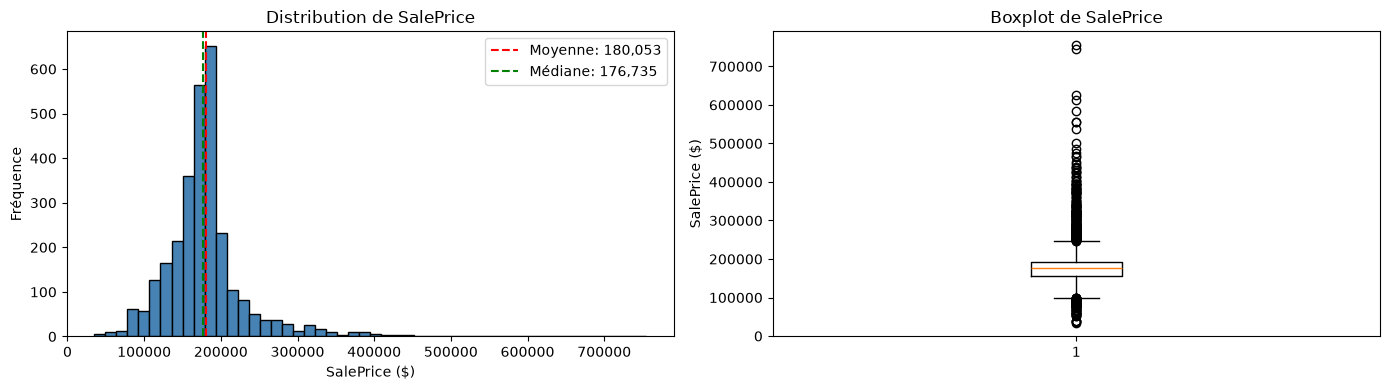

Skewness : 2.549
Kurtosis : 14.665


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution de SalePrice')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--',
                label=f'Moyenne: {df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='--',
                label=f'Médiane: {df["SalePrice"].median():,.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['SalePrice'], vert=True)
axes[1].set_title('Boxplot de SalePrice')
axes[1].set_ylabel('SalePrice ($)')

plt.tight_layout()
plt.show()

print(f"Skewness : {df['SalePrice'].skew():.3f}")
print(f"Kurtosis : {df['SalePrice'].kurtosis():.3f}")

In [90]:
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_price = df[(df['SalePrice'] < lower) | (df['SalePrice'] > upper)]

print(f"Q1  : {Q1:,.0f}")
print(f"Q3  : {Q3:,.0f}")
print(f"IQR : {IQR:,.0f}")
print(f"Borne inf : {lower:,.0f}")
print(f"Borne sup : {upper:,.0f}")
print(f"\nOutliers SalePrice : {len(outliers_price)} ({len(outliers_price)/len(df)*100:.1f}%)")

Q1  : 154,795
Q3  : 191,896
IQR : 37,101
Borne inf : 99,144
Borne sup : 247,547

Outliers SalePrice : 348 (11.9%)


In [91]:
Q1 = df['GrLivArea'].quantile(0.25)
Q3 = df['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

outliers_gr = df[df['GrLivArea'] > upper]
print(f"Borne sup GrLivArea : {upper:,.0f}")
print(f"Outliers GrLivArea  : {len(outliers_gr)} ({len(outliers_gr)/len(df)*100:.1f}%)")

# Les plus grandes surfaces avec leur prix
print("\nTop 5 plus grandes surfaces :")
print(df.nlargest(5, 'GrLivArea')[['Id', 'GrLivArea', 'SalePrice', 'OverallQual']])

Borne sup GrLivArea : 2,670
Outliers GrLivArea  : 74 (2.5%)

Top 5 plus grandes surfaces :
        Id  GrLivArea  SalePrice  OverallQual
1298  1299       5642 160,000.00           10
2549  2550       5095 230,841.34           10
523    524       4676 184,750.00           10
1182  1183       4476 745,000.00           10
691    692       4316 755,000.00           10


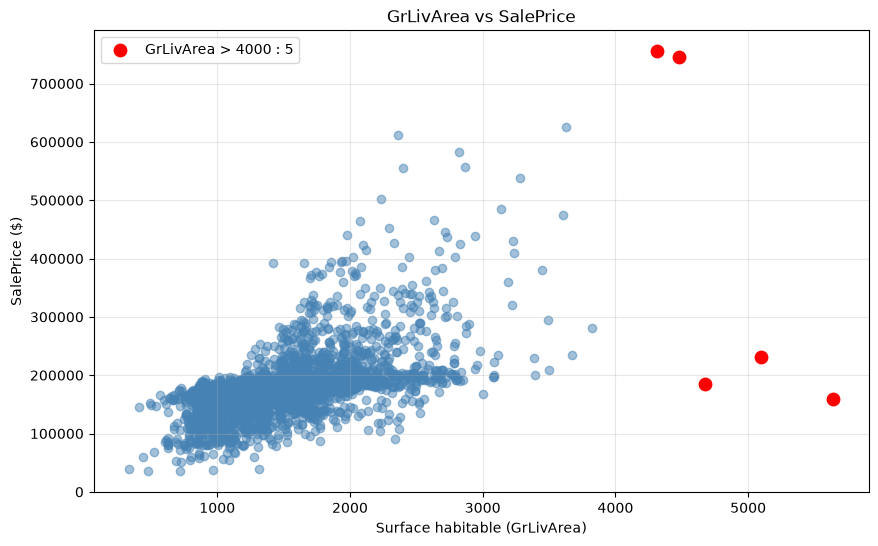

In [92]:
plt.figure(figsize=(10, 6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, color='steelblue')

mask = df['GrLivArea'] > 4000
plt.scatter(df.loc[mask, 'GrLivArea'], df.loc[mask, 'SalePrice'],
            color='red', s=80, label=f'GrLivArea > 4000 : {mask.sum()}')

plt.xlabel('Surface habitable (GrLivArea)')
plt.ylabel('SalePrice ($)')
plt.title('GrLivArea vs SalePrice')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [93]:
# ===== Suppression des 2 outliers extrêmes =====
mask_outliers = (df['GrLivArea'] > 4000) & (df['SalePrice'] < 200_000)

print(f"Outliers à supprimer : {mask_outliers.sum()}")
print(df.loc[mask_outliers, ['Id', 'GrLivArea', 'SalePrice', 'OverallQual']])

ids_supprimes = df.loc[mask_outliers, 'Id'].tolist()
print(f"\nId supprimés : {ids_supprimes}")

df = df[~mask_outliers].reset_index(drop=True)

print(f"\n✅ Shape après suppression : {df.shape}")
print(f"SalePrice moyenne : {df['SalePrice'].mean():,.0f}")
print(f"SalePrice médiane : {df['SalePrice'].median():,.0f}")
print(f"Skewness : {df['SalePrice'].skew():.3f}")

df.to_csv('../data/processed/train_clean.csv', index=False)
print(f"\n💾 Sauvegardé : data/processed/train_clean.csv")

Outliers à supprimer : 2
        Id  GrLivArea  SalePrice  OverallQual
523    524       4676 184,750.00           10
1298  1299       5642 160,000.00           10

Id supprimés : [524, 1299]

✅ Shape après suppression : (2917, 81)
SalePrice moyenne : 180,058
SalePrice médiane : 176,735
Skewness : 2.548

💾 Sauvegardé : data/processed/train_clean.csv


In [94]:
# ===== Séparation numériques / catégorielles =====
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numériques : {len(num_cols)}")
print(f"Catégorielles : {len(cat_cols)}")

Numériques : 38
Catégorielles : 43


In [95]:
# ===== Encodage ordinal + One-Hot =====
df_encoded = df.copy()

# Mappings ordinaux (issus de data_description.txt)
ORDRE_QUALITE = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ORDRE_EXPO    = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
ORDRE_FINTYPE = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
ORDRE_FINISH  = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
ORDRE_FUNC    = {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7}
ORDRE_FENCE   = {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}
ORDRE_GENERAL = {'None': 0, 'N': 0, 'No': 0, 'Y': 1, 'Yes': 1,
                 'ELO': 0, 'NoSeWa': 1, 'NoSewr': 2, 'AllPub': 3,
                 'Sev': 0, 'Mod': 1, 'Gtl': 2,
                 'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3,
                 'Grvl': 0, 'Pave': 1}

mappings = {
    'ExterQual': ORDRE_QUALITE, 'ExterCond': ORDRE_QUALITE,
    'BsmtQual': ORDRE_QUALITE, 'BsmtCond': ORDRE_QUALITE,
    'HeatingQC': ORDRE_QUALITE, 'KitchenQual': ORDRE_QUALITE,
    'FireplaceQu': ORDRE_QUALITE, 'GarageQual': ORDRE_QUALITE,
    'GarageCond': ORDRE_QUALITE, 'PoolQC': ORDRE_QUALITE,
    'BsmtExposure': ORDRE_EXPO,
    'BsmtFinType1': ORDRE_FINTYPE, 'BsmtFinType2': ORDRE_FINTYPE,
    'GarageFinish': ORDRE_FINISH,
    'Functional': ORDRE_FUNC, 'Fence': ORDRE_FENCE,
    'CentralAir': ORDRE_GENERAL, 'PavedDrive': ORDRE_GENERAL,
    'Utilities': ORDRE_GENERAL, 'LandSlope': ORDRE_GENERAL,
    'LotShape': ORDRE_GENERAL, 'Street': ORDRE_GENERAL,
    'Alley': ORDRE_GENERAL,
}

for col, mapping in mappings.items():
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(mapping).fillna(0).astype(int)

# One-Hot sur les catégorielles restantes
cat_restantes = df_encoded.select_dtypes(include=['object']).columns.tolist()
print(f"Catégorielles restantes (One-Hot) : {len(cat_restantes)}")

df_encoded = pd.get_dummies(df_encoded, columns=cat_restantes, drop_first=True, dtype=int)

print(f"\n✅ Shape après encodage : {df_encoded.shape}")
print(f"Toutes numériques : {df_encoded.select_dtypes(include=['object']).empty}")

Catégorielles restantes (One-Hot) : 20

✅ Shape après encodage : (2917, 202)
Toutes numériques : True


In [96]:
# ===== Split X / y + train/val AVANT scaling (évite data leakage) =====
from sklearn.model_selection import train_test_split

# 1. Séparer X et y
y = df_encoded['SalePrice'].reset_index(drop=True)
X = df_encoded.drop(columns=['Id', 'SalePrice']).reset_index(drop=True)

# 2. Split AVANT toute transformation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Split effectué AVANT scaling")
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_val   : {y_val.shape}")

✅ Split effectué AVANT scaling
X_train : (2333, 200)
X_val   : (584, 200)
y_train : (2333,)
y_val   : (584,)


In [97]:
# ===== Standardisation SANS data leakage =====
from sklearn.preprocessing import StandardScaler
import joblib

# Fit UNIQUEMENT sur train
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),   # ← fit_transform sur train
    columns=X_train.columns,
    index=X_train.index
)

# Transform (PAS fit) sur val
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),         # ← transform seulement sur val
    columns=X_val.columns,
    index=X_val.index
)

print(f"✅ Scaling appliqué sans fuite de données")
print(f"Moyennes train (≈0) : {X_train_scaled.mean().abs().max():.6f}")
print(f"Écart-types train (≈1) : {X_train_scaled.std().mean():.6f}")
print(f"Moyennes val (proches de 0) : {X_val_scaled.mean().abs().max():.6f}")
print(f"Écart-types val (proches de 1) : {X_val_scaled.std().mean():.6f}")

# Sauvegarde
joblib.dump(X_train_scaled, '../data/processed/X_train.pkl')
joblib.dump(X_val_scaled,   '../data/processed/X_val.pkl')
joblib.dump(y_train,        '../data/processed/y_train.pkl')
joblib.dump(y_val,          '../data/processed/y_val.pkl')
joblib.dump(scaler,         '../models/scaler.pkl')

print("\n💾 Fichiers sauvegardés :")
print("   - data/processed/X_train.pkl")
print("   - data/processed/X_val.pkl")
print("   - data/processed/y_train.pkl")
print("   - data/processed/y_val.pkl")
print("   - models/scaler.pkl")

✅ Scaling appliqué sans fuite de données
Moyennes train (≈0) : 0.000000
Écart-types train (≈1) : 0.990212
Moyennes val (proches de 0) : 0.165504
Écart-types val (proches de 1) : 0.920267

💾 Fichiers sauvegardés :
   - data/processed/X_train.pkl
   - data/processed/X_val.pkl
   - data/processed/y_train.pkl
   - data/processed/y_val.pkl
   - models/scaler.pkl
